In [5]:
# Import main libaries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [6]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [7]:
# Read dataset
image_path=[]
labels=[]
splits=[]
for split in os.listdir("/content/chest_xray/chest_xray"):
  split_path=f"/content/chest_xray/chest_xray/{split}"
  if not os.path.isdir(split_path):
    continue
  for label in os.listdir(split_path):
    label_path=f"{split_path}/{label}"
    if not os.path.isdir(label_path):
      continue

    for image in os.listdir(label_path):
      if image == '.DS_Store':
        continue
      image=f"{label_path}/{image}"
      image_path.append(image)
      labels.append(label)
      splits.append(split)

In [8]:
print(len(image_path),len(labels),len(splits))



5856 5856 5856


In [9]:
# convert into dataframe
df=pd.DataFrame({"image_path":image_path,"labels":labels,'splits':splits})

In [10]:
df.shape

(5856, 3)

In [11]:
# Split train val and test
train_data=df[df['splits']=='train'].reset_index(drop=True)
val_data=df[df['splits']=='val'].reset_index  (drop=True)
test_data=df[df['splits']=='test'].reset_index(drop=True)

In [12]:
print(train_data.shape,val_data.shape,test_data.shape)

(5216, 3) (16, 3) (624, 3)


In [13]:
# Remove splits column
train_data=train_data.drop('splits',axis=1)
val_data=val_data.drop('splits',axis=1)
test_df=test_data.drop('splits',axis=1)

In [14]:
# Val dataset is low so split it equally
temp_df=pd.concat([train_data,val_data],axis=0).reset_index(drop=True)
from sklearn.model_selection import train_test_split
train_df,val_df=train_test_split(temp_df,test_size=0.12,stratify=temp_df['labels'],random_state=42)

In [15]:
train_df['labels'].value_counts() # looks imbalanced

,count
labels,
PNEUMONIA,3417
NORMAL,1187


In [16]:
# encode labels column
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
train_df['labels']=labelencoder.fit_transform(train_df['labels'])
test_df['labels']=labelencoder.transform(test_df['labels'])
val_df['labels']=labelencoder.transform(val_df['labels'])

In [17]:
# Create transform
from torchvision import transforms
train_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


val_test_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [18]:
# Create custom DataSet
from torch.utils.data import Dataset
from PIL import Image
class ChestXRayDataset(Dataset):
  def __init__(self,df,transform=None):
    self.df=df.reset_index(drop=True)
    self.transform=transform
    self.labels=torch.tensor(self.df['labels'].values,dtype=torch.float32)

  def __len__(self):
    return len(self.df)

  def __getitem__(self, index):
    image_path=self.df.iloc[index,0]

    # convert RGB
    image=Image.open(image_path).convert('RGB')

    if self.transform is not None:
      image=self.transform(image)

    return image,self.labels[index]


In [19]:
train_dataset=ChestXRayDataset(train_df,transform=train_transform)
val_dataset=ChestXRayDataset(val_df,transform=val_test_transform)
test_dataset=ChestXRayDataset(test_df,transform=val_test_transform)

In [20]:
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import DataLoader

# Compute per-sample weights
class_counts = train_df['labels'].value_counts()
sample_weights = train_df['labels'].map(lambda x: 1.0 / class_counts[x]).values

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# sampler in DataLoader
train_dataloader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
from torchvision import models
import torch.nn as nn
model=models.efficientnet_b3(pretrained=True)

for param in model.features.parameters():
  param.requires_grad=True

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 180MB/s]


In [22]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [23]:
model.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1000, bias=True)
)

In [24]:
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(1536, 1)
)
model = model.to(device)

In [25]:
learninig_rate=0.00001
epochs=25
loss_fun=nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learninig_rate,weight_decay=1e-4)

In [ ]:
train_loss_graph = []
val_loss_graph   = []
train_acc_graph  = []
val_acc_graph    = []

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 5

for epoch in range(epochs):
    avg_train_loss = 0
    avg_train_acc  = 0
    avg_val_loss   = 0
    avg_val_acc    = 0

    model.train()
    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        pred = model(inputs).squeeze(1)
        train_loss = loss_fun(pred, labels)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        avg_train_loss += train_loss.item()
        predicted = (torch.sigmoid(pred) >= 0.5).long()
        avg_train_acc += (predicted == labels.long()).sum().item()

    model.eval()
    with torch.no_grad():
        for images, labels in val_dataloader:
            images = images.to(device)
            labels = labels.to(device)

            pred = model(images).squeeze(1)
            val_loss = loss_fun(pred, labels)

            avg_val_loss += val_loss.item()
            predicted = (torch.sigmoid(pred) >= 0.5).long()
            avg_val_acc += (predicted == labels.long()).sum().item()

    avg_train_loss /= len(train_dataloader)
    avg_train_acc  /= len(train_dataset)
    avg_val_loss   /= len(val_dataloader)
    avg_val_acc    /= len(val_dataset)

    train_loss_graph.append(avg_train_loss)
    val_loss_graph.append(avg_val_loss)
    train_acc_graph.append(avg_train_acc)
    val_acc_graph.append(avg_val_acc)

    print(f"Epoch {epoch+1} | train_loss: {avg_train_loss:.4f} | val_loss: {avg_val_loss:.4f} | train_acc: {avg_train_acc:.4f} | val_acc: {avg_val_acc:.4f}")

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ✓ Best model saved (val_loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Epoch 1 | train_loss: 0.5885 | val_loss: 0.5161 | train_acc: 0.8254 | val_acc: 0.8439
  ✓ Best model saved (val_loss: 0.5161)
Epoch 2 | train_loss: 0.3520 | val_loss: 0.3077 | train_acc: 0.9322 | val_acc: 0.8997
  ✓ Best model saved (val_loss: 0.3077)
Epoch 3 | train_loss: 0.1968 | val_loss: 0.2338 | train_acc: 0.9490 | val_acc: 0.9188
  ✓ Best model saved (val_loss: 0.2338)
Epoch 4 | train_loss: 0.1467 | val_loss: 0.1329 | train_acc: 0.9568 | val_acc: 0.9506
  ✓ Best model saved (val_loss: 0.1329)
Epoch 5 | train_loss: 0.1115 | val_loss: 0.1056 | train_acc: 0.9661 | val_acc: 0.9570
  ✓ Best model saved (val_loss: 0.1056)
Epoch 6 | train_loss: 0.1100 | val_loss: 0.1046 | train_acc: 0.9624 | val_acc: 0.9538
  ✓ Best model saved (val_loss: 0.1046)
Epoch 7 | train_loss: 0.0811 | val_loss: 0.0801 | train_acc: 0.9748 | val_acc: 0.9666
  ✓ Best model saved (val_loss: 0.0801)
Epoch 8 | train_loss: 0.0839 | val_loss: 0.0869 | train_acc: 0.9707 | val_acc: 0.9634
  No improvement (1/5)
Epoch 9 |

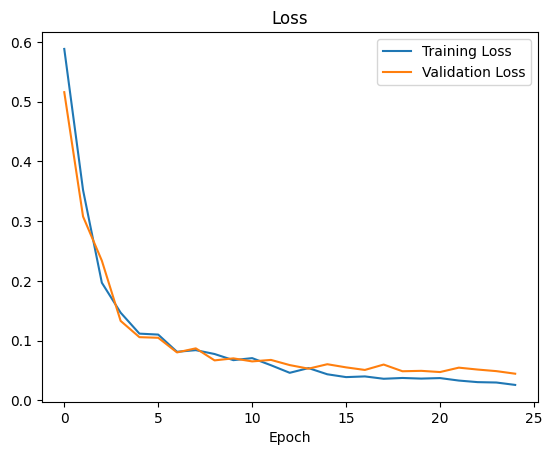

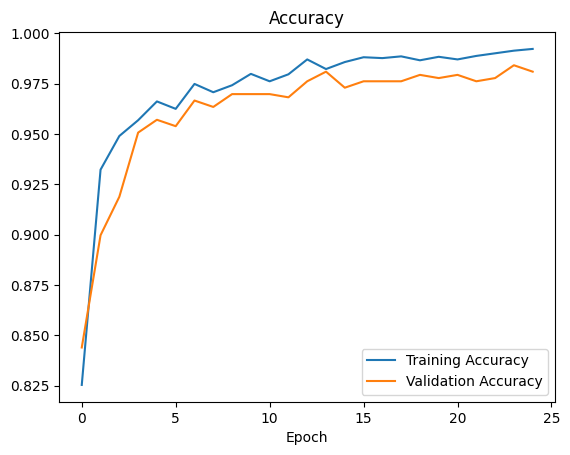

In [36]:
sns.lineplot(x=range(len(train_loss_graph)), y=train_loss_graph, label="Training Loss")
sns.lineplot(x=range(len(val_loss_graph)),   y=val_loss_graph,   label="Validation Loss")
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

sns.lineplot(x=range(len(train_acc_graph)), y=train_acc_graph, label="Training Accuracy")
sns.lineplot(x=range(len(val_acc_graph)),   y=val_acc_graph,   label="Validation Accuracy")
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.show()

In [34]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds  = []
all_labels = []
all_raw_preds = []
total_loss_test = 0
total_acc_test  = 0

with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        pred      = model(inputs).squeeze(1)
        test_loss = loss_fun(pred, labels)

        total_loss_test += test_loss.item()
        predicted        = (torch.sigmoid(pred) >= 0.98).long()
        all_raw_preds.extend(pred.cpu().numpy())
        total_acc_test  += (predicted == labels.long()).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.long().cpu().numpy())

print(f"Accuracy Score: {total_acc_test/len(test_dataset):.4f} "
      f"Loss Score: {total_loss_test/len(test_dataloader):.4f}")


from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA']))

Accuracy Score: 0.9439 Loss Score: 0.4232
              precision    recall  f1-score   support

      NORMAL       0.94      0.91      0.92       234
   PNEUMONIA       0.94      0.97      0.96       390

    accuracy                           0.94       624
   macro avg       0.94      0.94      0.94       624
weighted avg       0.94      0.94      0.94       624



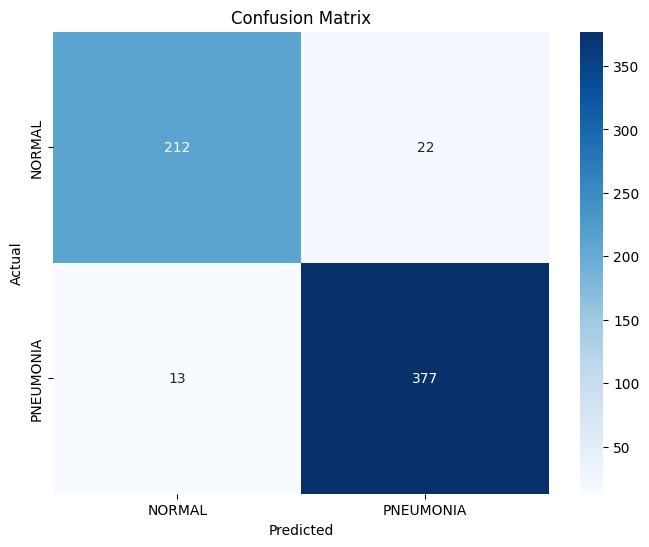

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Build confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()